#### Introduction to Brian Part 1: Neurons

In [2]:
from brian2 import *

In [3]:
%matplotlib inline

In [4]:
12.5 * volt

12.5 * volt

In [5]:
5000 * amp

5. * kamp

In [6]:
1e6 * volt

1. * Mvolt

In [7]:
100 * namp

100. * namp

In [8]:
10 * nA * 5 * Mohm

50. * mvolt

In [9]:
tau = 10 * ms
eqs = '''
dv/dt = (1 - v)/tau : 1
'''

G = NeuronGroup(1, eqs, method="exact")
print(f"Before: v = {G.v[0]}")
run(100*ms)
print(f"After: v = {G.v[0]}")

Before: v = 0.0


WARNING    Removing unsupported flag '-march=native' from compiler flags. [brian2.codegen.cpp_prefs]
WARNING    Cannot use Cython, a test compilation failed: Cython is not available (ImportError)
Certain compiler configurations (e.g. clang in a conda environment on OS X) are known to be problematic. Note that you can switch the compiler by setting the 'CC' and 'CXX' environment variables. For example, you may want to try 'CC=gcc' and 'CXX=g++'. [brian2.codegen.runtime.cython_rt.cython_rt.failed_compile_test]
INFO       Cannot use compiled code, falling back to the numpy code generation target. Note that this will likely be slower than using compiled code. Set the code generation to numpy manually to avoid this message:
prefs.codegen.target = "numpy" [brian2.devices.device.codegen_fallback]


After: v = 0.9999546000702376


In [10]:
print(f"Expected value of v = {1 - exp(-100 * ms / tau)}")

Expected value of v = 0.9999546000702375


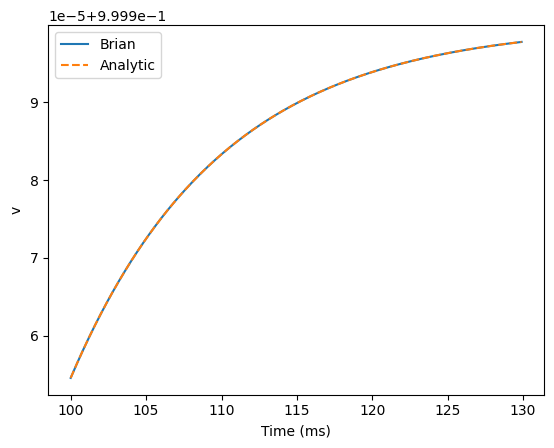

In [11]:
M = StateMonitor(G, "v", record=0)

run(30 * ms)
plot(M.t/ms, M.v[0], label="Brian") # Plotting voltage over time from NeuronGroup
plot(M.t/ms, 1-exp(-M.t/tau), "C1--", label="Analytic") # Expected # behavior of function
xlabel("Time (ms)")
ylabel("v")
plt.legend();

In [12]:
start_scope()

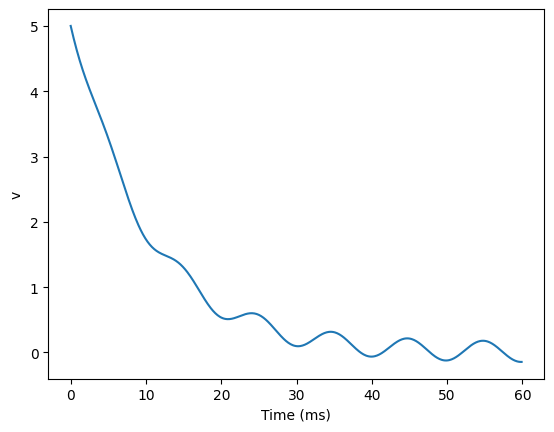

In [13]:
tau = 10 * ms
eqs = """
dv/dt = (sin(2 * pi * 100 * Hz * t)-v)/tau : 1
"""

G = NeuronGroup(1, eqs, method="euler")
M = StateMonitor(G, "v", record=0)

G.v = 5

run(60 * ms)

plt.plot(M.t/ms, M.v[0])
plt.xlabel("Time (ms)")
plt.ylabel("v");

#### Spiking Behavior by Setting Threshold

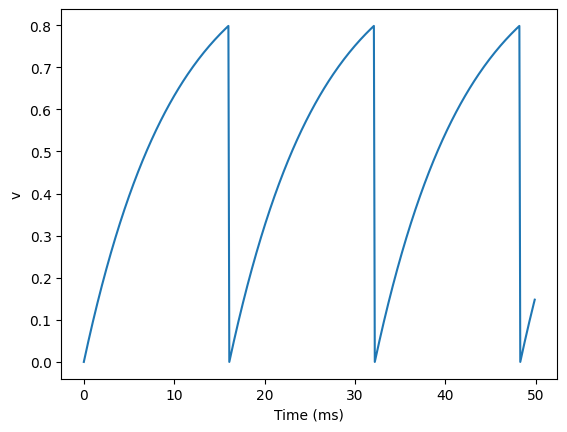

In [14]:
tau = 10 * ms
eqs = """
dv/dt = (1 - v)/tau : 1
"""

G = NeuronGroup(1, eqs, threshold="v > 0.8", reset="v = 0", method="exact") # 1 neuron based on the differential equation defined in eq; threshold met when v > 0.8; voltage reset to 0

M = StateMonitor(G, "v", record=0)
run(50 * ms)

plt.plot(M.t/ms, M.v[0])
plt.xlabel("Time (ms)")
plt.ylabel("v");



In [15]:
start_scope()
G = NeuronGroup(1, eqs, threshold="v > 0.8", reset="v = 0", method="exact")

spike_monitor = SpikeMonitor(G)

run(50 * ms)

print(f"Spike times: {spike_monitor.t[:]}") # Spike times from variable t

Spike times: [16.  32.1 48.2] ms


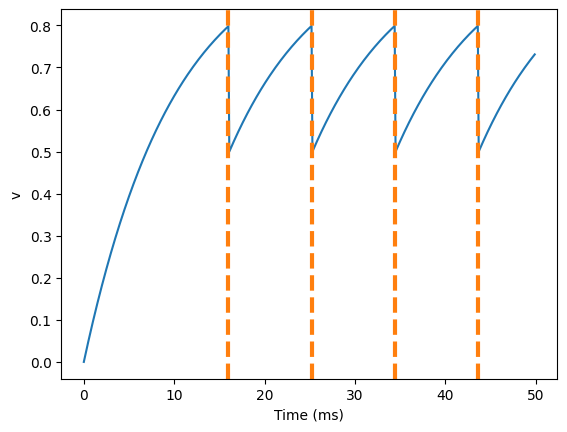

In [16]:
start_scope()

G = NeuronGroup(1, eqs, threshold="v > 0.8", reset="v = 0.50", method="exact")

state_monitor = StateMonitor(G, "v", record=0)
spike_monitor = SpikeMonitor(G) # Spike monitor of neuron group

run(50 * ms)
plt.plot(state_monitor.t/ms, state_monitor.v[0])
for t in spike_monitor.t:
    plt.axvline(t/ms, ls="--", c="C1", lw=3) # Vertical line at t/ms with line style -- and line width of 3.

plt.xlabel("Time (ms)")
plt.ylabel("v");

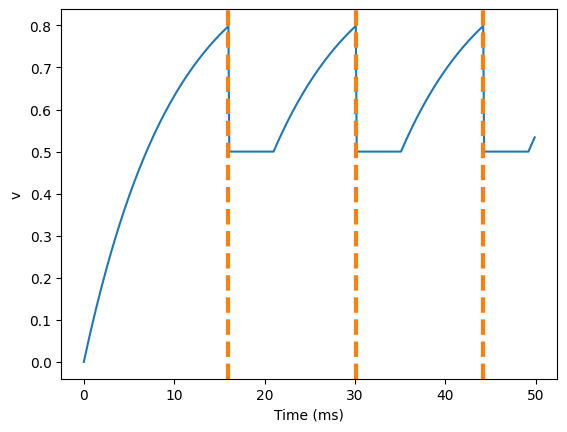

In [17]:
start_scope()

tau = 10 * ms
eqs = """
dv/dt = (1 - v) / tau: 1 (unless refractory)
"""
G = NeuronGroup(1, eqs, threshold="v > 0.8", reset="v = 0.50", refractory= 5*ms, method="exact")

state_monitor = StateMonitor(G, "v", record=0)
spike_monitor = SpikeMonitor(G) # Spike monitor of neuron group

run(50 * ms)
plt.plot(state_monitor.t/ms, state_monitor.v[0])
for t in spike_monitor.t:
    plt.axvline(t/ms, ls="--", c="C1", lw=3) # Vertical line at t/ms with line style -- and line width of 3.

plt.xlabel("Time (ms)")
plt.ylabel("v");

Spike times: [ 8. 23. 38.] ms


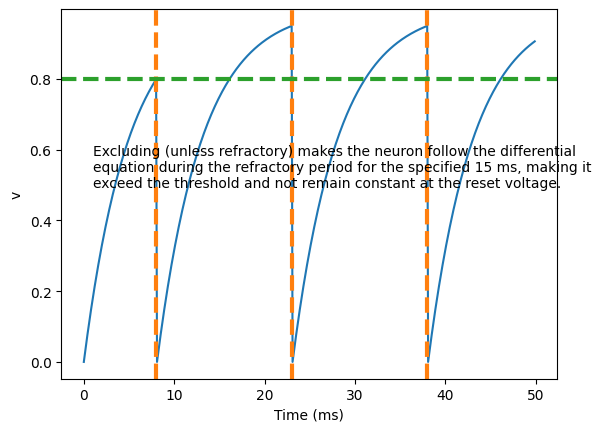

In [18]:
start_scope()

tau = 5 * ms # Tau increased to 5
eqs = """
dv/dt = (1 - v) / tau: 1
"""
G = NeuronGroup(1, eqs, threshold="v > 0.8", reset="v = 0", refractory= 15*ms, method="exact") # Refractory period increased to 15 ms

state_monitor = StateMonitor(G, "v", record=0)
spike_monitor = SpikeMonitor(G) # Spike monitor of neuron group

run(50 * ms)
plt.plot(state_monitor.t/ms, state_monitor.v[0])
for t in spike_monitor.t:
    plt.axvline(t/ms, ls="--", c="C1", lw=3) # Vertical line at t/ms with line style -- and line width of 3.
plt.axhline(0.8, ls="--", c="C2", lw=3)
plt.xlabel("Time (ms)")
plt.ylabel("v")
plt.annotate("Excluding (unless refractory) makes the neuron follow the differential equation during the refractory period for the specified 15 ms, making it exceed the threshold and not remain constant at the reset voltage.", (1, 0.5), wrap=True, fontsize=10)
print(f"Spike times: {spike_monitor.t[:]}")

#### Multiple Neurons

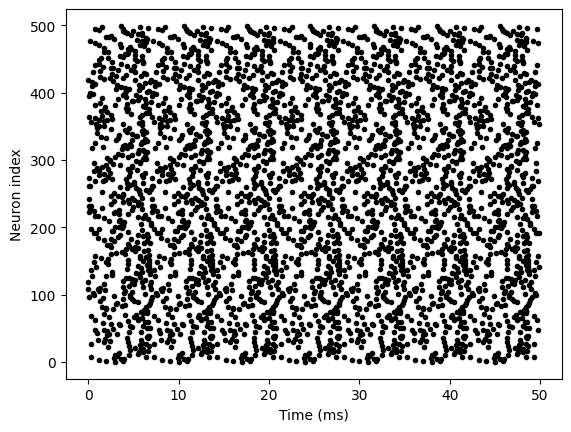

In [19]:
start_scope()

N = 500 # 500 neurons
tau = 10 * ms
eqs="""
dv/dt = (2 - v) / tau: 1
"""

G = NeuronGroup(N, eqs, threshold="v > 1", reset="v = 0", method="exact")
G.v = "rand()"

spike_monitor = SpikeMonitor(G)

run(50 * ms)

plt.plot(spike_monitor.t/ms, spike_monitor.i, ".k")
plt.xlabel("Time (ms)")
plt.ylabel("Neuron index"); # "Raster plot"

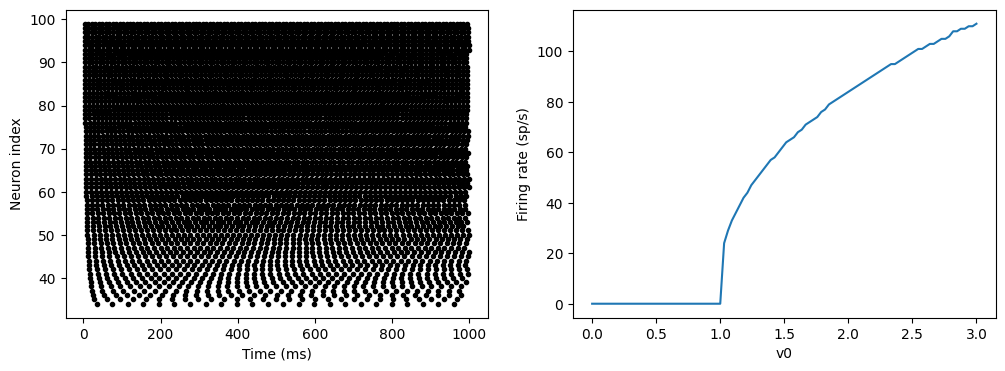

In [22]:
start_scope()

N = 100 # 100 neurons
tau = 10 * ms
v0_max = 3.
duration = 1000 * ms
eqs="""
dv/dt = (v0 - v) / tau: 1 (unless refractory)
v0: 1
"""

G = NeuronGroup(N, eqs, threshold="v > 1", reset="v = 0", refractory=5 * ms, method="exact")
spike_monitor = SpikeMonitor(G)

G.v0 = "i * v0_max/(N-1)"

run(duration)

plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.plot(spike_monitor.t/ms, spike_monitor.i, ".k")
plt.xlabel("Time (ms)")
plt.ylabel("Neuron index")
plt.subplot(122)
plt.plot(G.v0, spike_monitor.count/duration)
plt.xlabel("v0")
plt.ylabel("Firing rate (sp/s)"); # "Raster plot"

Text(0, 0.5, 'Voltage (v)')

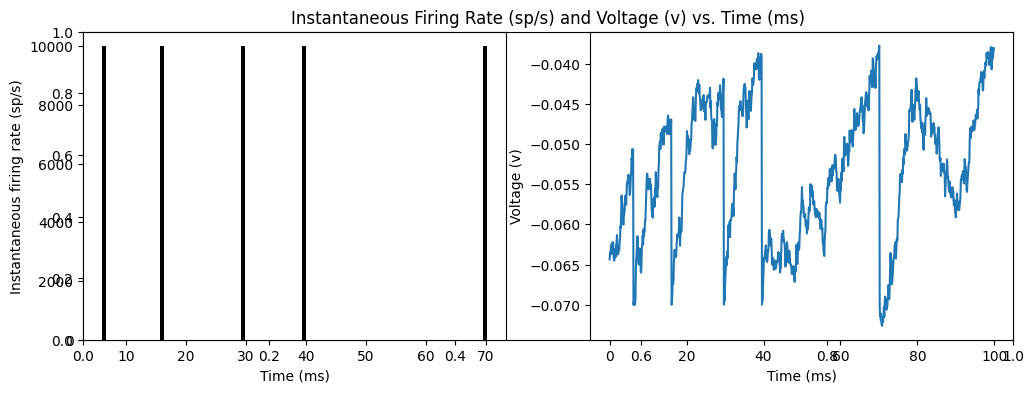

In [60]:
start_scope()

N = 1
tau = 10 * ms
vr = -70 * mV
vt0 = -50 * mV
delta_vt0 = 5 * mV
tau_t = 100 * ms
sigma = 0.5 * (vt0-vr)
v_drive = 2 * (vt0 - vr)
duration = 100 * ms

eqs = """
dv/dt = (v_drive + vr-v)/tau + sigma*xi*tau**-0.5 : volt
dvt/dt = (vt0 - vt) / tau_t : volt
"""

reset = """
v = vr
vt += delta_vt0
"""

G = NeuronGroup(N, eqs, threshold="v>vt", reset=reset, refractory=5*ms, method="euler")
spike_monitor = SpikeMonitor(G)
state_monitor = StateMonitor(G, "v", record=0)
G.v = "rand()*(vt0 - vr) + vr"
G.vt = vt0

run(duration)

plt.figure(figsize=(12, 4))
plt.title("Instantaneous Firing Rate (sp/s) and Voltage (v) vs. Time (ms)")
plt.subplot(121)
_ = plt.hist(spike_monitor.t/ms, 100, histtype="stepfilled", facecolor="k", weights=list(ones(len(spike_monitor))/(N*defaultclock.dt)))
plt.xlabel("Time (ms)")
plt.ylabel("Instantaneous firing rate (sp/s)")

plt.subplot(122)
plt.plot(state_monitor.t/ms, state_monitor.v[0])
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (v)")